In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid", palette="pastel")

# Carrega os datasets voltando DUAS pastas (../../) para chegar à raiz do projeto
df = pd.read_csv('../../data/processed/olist_super_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Carregando a tabela de pagamentos da mesma forma
pagamentos_raw = pd.read_csv('../../data/raw/olist_order_payments_dataset.csv')

### 💳 1. O Efeito do Parcelamento no Ticket Médio

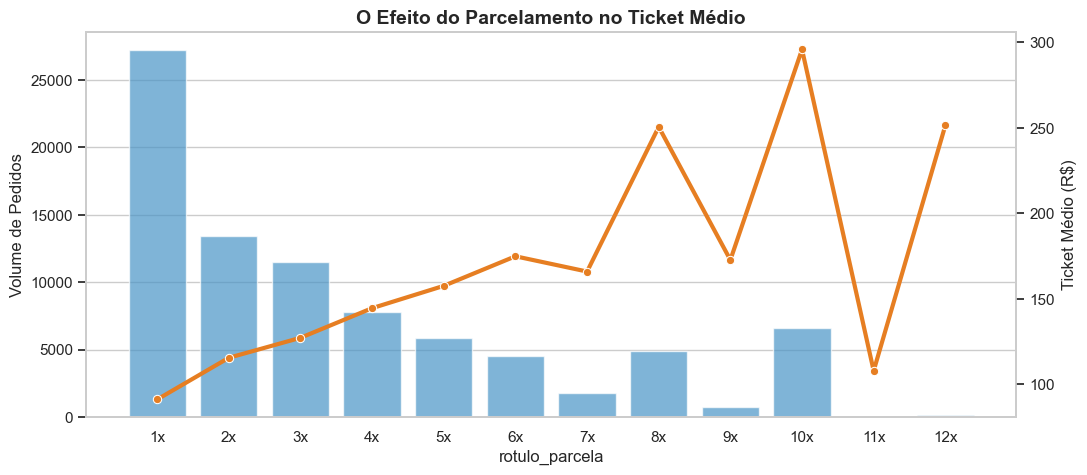

In [2]:
df_completo = df.merge(pagamentos_raw[['order_id', 'payment_type', 'payment_installments']], on='order_id', how='inner')
df_credito = df_completo[df_completo['payment_type'] == 'credit_card'].copy()

analise_parcelas = df_credito.groupby('payment_installments').agg(
    volume_pedidos=('order_id', 'count'), ticket_medio=('receita_liquida', 'mean')
).reset_index()

analise_parcelas = analise_parcelas[(analise_parcelas['payment_installments'] >= 1) & (analise_parcelas['payment_installments'] <= 12)].copy()
analise_parcelas['rotulo_parcela'] = analise_parcelas['payment_installments'].astype(str) + "x"

fig, ax1 = plt.subplots(figsize=(12, 5))
color_bar = '#3498db'
sns.barplot(x='rotulo_parcela', y='volume_pedidos', data=analise_parcelas, ax=ax1, color=color_bar, alpha=0.7)
ax1.set_ylabel('Volume de Pedidos')

ax2 = ax1.twinx()
color_line = '#e67e22'
sns.lineplot(x='rotulo_parcela', y='ticket_medio', data=analise_parcelas, ax=ax2, color=color_line, marker='o', linewidth=3, sort=False)
ax2.set_ylabel('Ticket Médio (R$)')
ax2.grid(False)

plt.title('O Efeito do Parcelamento no Ticket Médio', fontsize=14, fontweight='bold')
plt.show()

> **💡 Insight de Negócio: O Poder de Compra**
> O gráfico revela uma correlação direta: o consumidor depende do **parcelamento longo (10x a 12x)** para adquirir produtos *High Ticket*. 

### 📊 2. A Preferência de Parcelamento e o Volume de Vendas

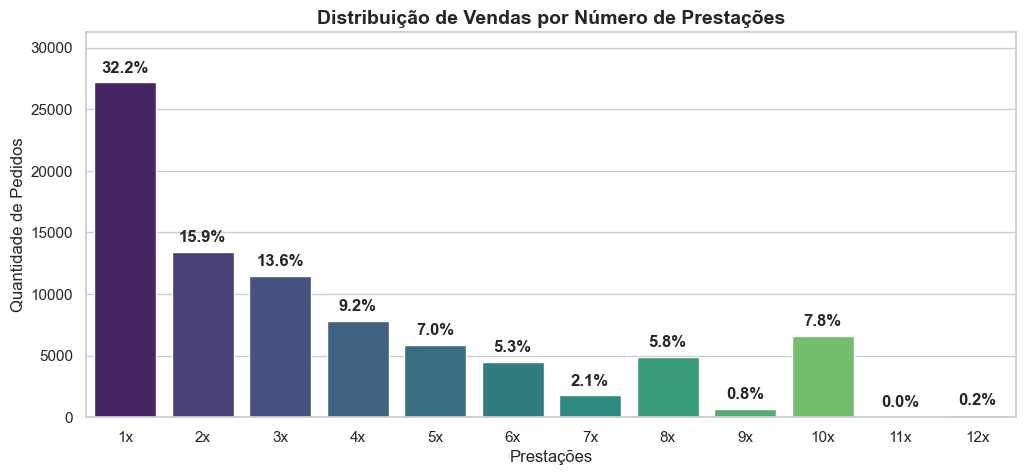

In [3]:
volume_parcelas = df_credito.groupby('payment_installments').agg(quantidade_vendas=('order_id', 'count')).reset_index()
volume_parcelas = volume_parcelas[(volume_parcelas['payment_installments'] >= 1) & (volume_parcelas['payment_installments'] <= 12)].copy()

total_vendas = volume_parcelas['quantidade_vendas'].sum()
volume_parcelas['percentagem'] = (volume_parcelas['quantidade_vendas'] / total_vendas) * 100
volume_parcelas['rotulo_parcela'] = volume_parcelas['payment_installments'].astype(str) + "x"

plt.figure(figsize=(12, 5))
ax = sns.barplot(x='rotulo_parcela', y='quantidade_vendas', data=volume_parcelas, hue='rotulo_parcela', palette="viridis", legend=False)

plt.title('Distribuição de Vendas por Número de Prestações', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Pedidos')
plt.xlabel('Prestações')

for i, p in enumerate(ax.patches):
    ax.annotate(f"{volume_parcelas['percentagem'].iloc[i]:.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.ylim(0, volume_parcelas['quantidade_vendas'].max() * 1.15)
plt.show()

> **💡 Insight de Negócio: O Rei do Volume**
> Apesar das prestações longas viabilizarem o lucro em itens caros, este gráfico prova que o **pagamento à vista (1x)** é o verdadeiro motor da plataforma, dominando mais de **30%** do volume de cartões.

### 🚚 3. O Impacto do Atraso Logístico na Satisfação (NPS)

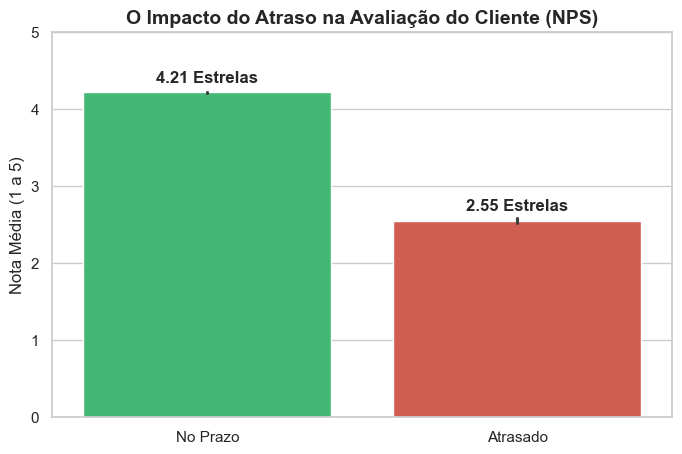

In [4]:
# 1. Mapear o status e limpar clientes que não deixaram nota (evita o gráfico em branco)
df['status_entrega'] = df['atraso_entrega'].map({False: 'No Prazo', True: 'Atrasado'})
df_grafico = df.dropna(subset=['review_score', 'status_entrega']).copy()

# 2. Criar a figura
plt.figure(figsize=(8, 5))

# 3. Desenhar o gráfico de barras
ax = sns.barplot(
    x='status_entrega', 
    y='review_score', 
    data=df_grafico, 
    hue='status_entrega', 
    palette=['#2ecc71', '#e74c3c'], 
    legend=False
)

# 4. Ajustar títulos e eixos
plt.title('O Impacto do Atraso na Avaliação do Cliente (NPS)', fontsize=14, fontweight='bold')
plt.ylabel('Nota Média (1 a 5)')
plt.xlabel('')
plt.ylim(0, 5)

# 5. Colocar os números em cima das barras
for p in ax.patches:
    altura = p.get_height()
    # Confirmação extra para garantir que o número existe antes de escrever
    if pd.notna(altura) and altura > 0:
        ax.annotate(f"{altura:.2f} Estrelas", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', fontsize=12)

plt.show()

> **💡 Insight de Negócio: O Custo da Ineficiência**
> A logística é o principal pilar da reputação da marca. Encomendas no prazo mantêm um padrão de excelência (**> 4 estrelas**), mas basta um dia de atraso para a nota **desabar quase 50%**.

### 🏆 4. Lucro: Ticket Médio (Receita) por Categoria

C:\Users\Almox\AppData\Local\Temp\ipykernel_15152\2143541697.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


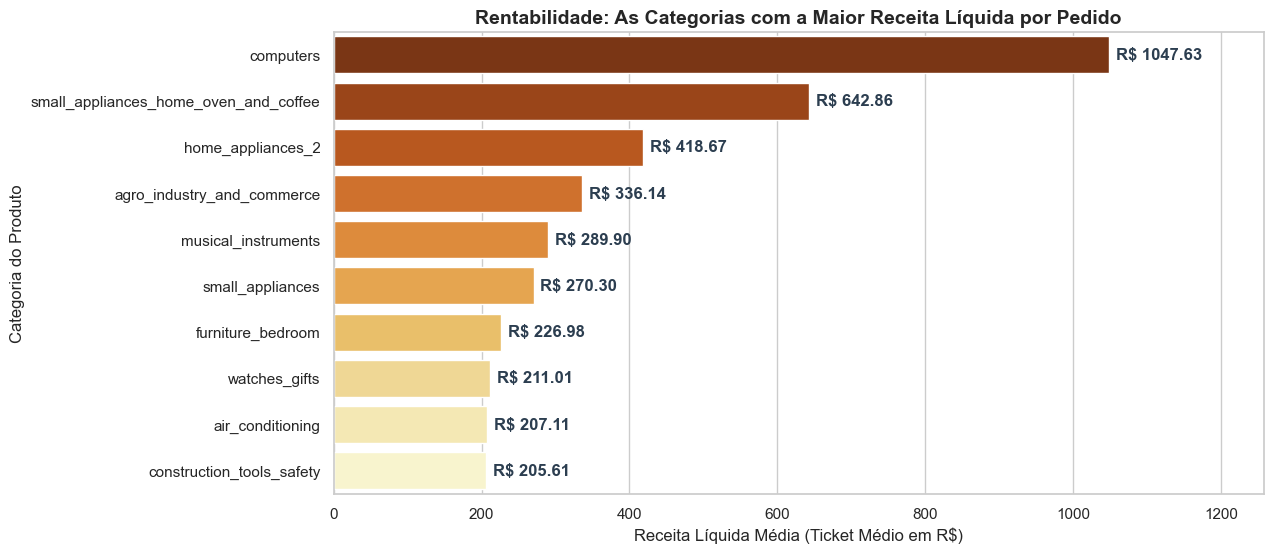

In [5]:
# 1. Agrupar por categoria calculando o Ticket Médio (Receita Média) e o Volume de Vendas
lucro_categoria = df.groupby('product_category_name_english').agg(
    ticket_medio=('receita_liquida', 'mean'),
    volume_vendas=('order_id', 'count')
).reset_index()

# 2. Filtrar apenas categorias consolidadas (mais de 50 vendas) para evitar distorções matemáticas
lucro_categoria = lucro_categoria[lucro_categoria['volume_vendas'] > 50]

# 3. Pegar as 10 categorias com a maior Receita Líquida Média por pedido
top_ticket = lucro_categoria.nlargest(10, 'ticket_medio')

# 4. Desenhar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='ticket_medio', 
    y='product_category_name_english', 
    data=top_ticket, 
    palette='YlOrBr_r'
)

plt.title('Rentabilidade: As Categorias com a Maior Receita Líquida por Pedido', fontsize=14, fontweight='bold')
plt.xlabel('Receita Líquida Média (Ticket Médio em R$)')
plt.ylabel('Categoria do Produto')

# 5. Adicionar o valor financeiro à frente das barras
for p in ax.patches:
    valor = p.get_width()
    if pd.notna(valor) and valor > 0:
        ax.annotate(f"R$ {valor:.2f}", 
                    (valor, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), textcoords='offset points', 
                    fontweight='bold', color='#2c3e50')

# Ajustar o limite do eixo X para o texto não ser cortado à direita
plt.xlim(0, top_ticket['ticket_medio'].max() * 1.20)
plt.show()

> **💡 Insight de Negócio: A Mina de Ouro do "High Ticket"**
> Enquanto categorias como "Beleza e Saúde" vendem um volume gigantesco de itens baratos, este gráfico revela onde está a verdadeira margem de lucro por unidade. Categorias como **Computadores (PCs)** e **Eletrodomésticos (Small Appliances e Ovens)** geram, em média, de **R$ 500 a R$ 1.100 por única venda**.

### 🗺️ 5. O Poder da Vitrine: Quantidade de Fotos vs. Vendas

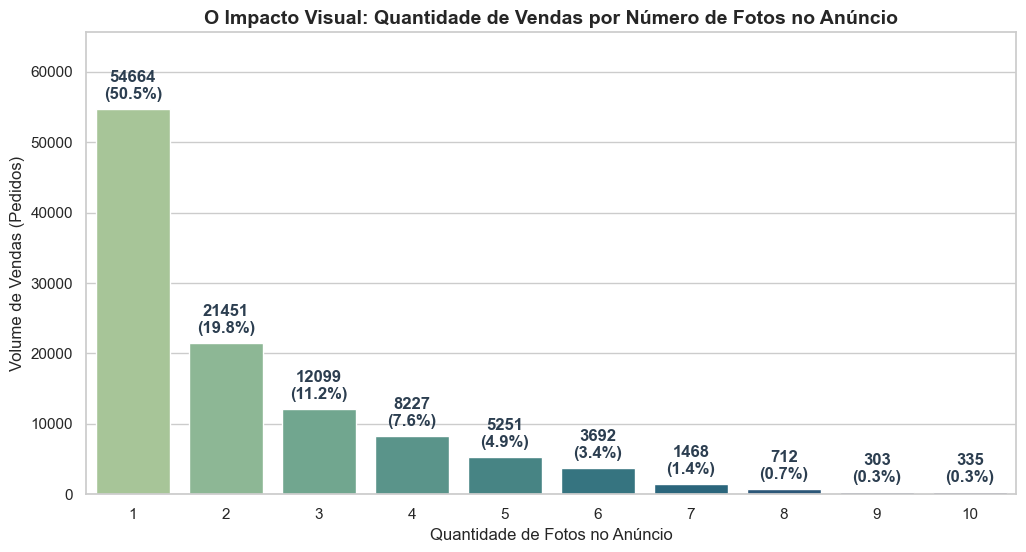

In [6]:
# 1. Agrupar os dados pela quantidade de fotos do produto e contar os pedidos
vendas_por_foto = df.groupby('product_photos_qty').agg(
    quantidade_vendas=('order_id', 'count')
).reset_index()

# 2. Filtrar para produtos de 1 a 10 fotos (onde se concentra +95% do volume)
vendas_por_foto = vendas_por_foto[(vendas_por_foto['product_photos_qty'] >= 1) & 
                                  (vendas_por_foto['product_photos_qty'] <= 10)].copy()

# 3. Converter para número inteiro para o eixo X ficar limpo (sem casas decimais)
vendas_por_foto['product_photos_qty'] = vendas_por_foto['product_photos_qty'].astype(int)

# 4. Calcular a representatividade em %
total_analisado = vendas_por_foto['quantidade_vendas'].sum()
vendas_por_foto['percentagem'] = (vendas_por_foto['quantidade_vendas'] / total_analisado) * 100

# 5. Desenhar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='product_photos_qty', 
    y='quantidade_vendas', 
    data=vendas_por_foto, 
    hue='product_photos_qty',
    palette='crest',
    legend=False
)

plt.title('O Impacto Visual: Quantidade de Vendas por Número de Fotos no Anúncio', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Fotos no Anúncio')
plt.ylabel('Volume de Vendas (Pedidos)')

# 6. Adicionar o volume absoluto e a % em cima das barras
for i, p in enumerate(ax.patches):
    altura = p.get_height()
    pct = vendas_por_foto['percentagem'].iloc[i]
    if pd.notna(altura) and altura > 0:
        ax.annotate(f"{int(altura)}\n({pct:.1f}%)", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', color='#2c3e50')

# Ajustar o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, vendas_por_foto['quantidade_vendas'].max() * 1.20)
plt.show()

> **💡 Insight de Negócio: O Paradoxo do Esforço Visual**
> Curiosamente, o gráfico demonstra que a esmagadora maioria das conversões (mais de **50%**) acontece em anúncios que possuem **apenas 1 foto**. Isso indica duas coisas: ou o catálogo da Olist é dominado por produtos padronizados (onde o cliente já sabe exatamente o que está a comprar, não precisando de mais ângulos), ou os *Sellers* estão a ser extremamente negligentes no cadastro de novos produtos.

### 🔄 6. A Ilusão da Recorrência (Taxa de Retenção de Clientes)

C:\Users\Almox\AppData\Local\Temp\ipykernel_15152\4175027229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='numero_de_compras', y='quantidade_clientes', data=distribuicao_recompra, palette='Blues_r')


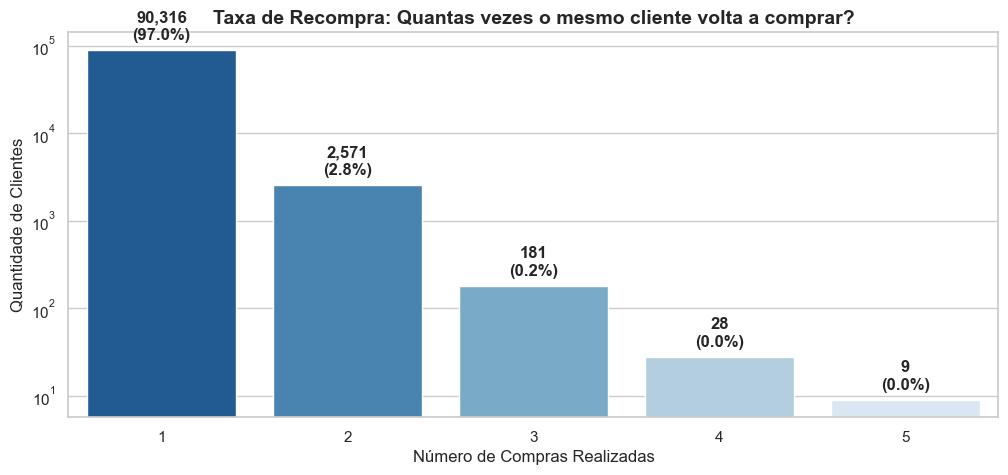

In [7]:
# Contar quantos pedidos únicos cada cliente (por CPF/ID único) fez na plataforma
compras_por_cliente = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
compras_por_cliente.columns = ['customer_unique_id', 'numero_de_compras']

# Agrupar para ver quantos clientes compraram 1 vez, 2 vezes, etc.
distribuicao_recompra = compras_por_cliente['numero_de_compras'].value_counts().reset_index()
distribuicao_recompra.columns = ['numero_de_compras', 'quantidade_clientes']

# Limitar a visualização até 5 compras para o gráfico ficar limpo
distribuicao_recompra = distribuicao_recompra[distribuicao_recompra['numero_de_compras'] <= 5]
total_clientes = distribuicao_recompra['quantidade_clientes'].sum()
distribuicao_recompra['percentagem'] = (distribuicao_recompra['quantidade_clientes'] / total_clientes) * 100

plt.figure(figsize=(12, 5))
ax = sns.barplot(x='numero_de_compras', y='quantidade_clientes', data=distribuicao_recompra, palette='Blues_r')

plt.title('Taxa de Recompra: Quantas vezes o mesmo cliente volta a comprar?', fontsize=14, fontweight='bold')
plt.xlabel('Número de Compras Realizadas')
plt.ylabel('Quantidade de Clientes')
plt.yscale('log') # Escala logarítmica para conseguir visualizar as barras menores

for i, p in enumerate(ax.patches):
    pct = distribuicao_recompra['percentagem'].iloc[i]
    qtd = distribuicao_recompra['quantidade_clientes'].iloc[i]
    ax.annotate(f"{qtd:,.0f}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

> **💡 Insight de Negócio: O Motor de Aquisição vs. Retenção**
> O gráfico é assustadoramente claro: **mais de 96% dos clientes** neste dataset realizaram apenas **uma única compra**. A Olist funciona perfeitamente como uma máquina de topo de funil (aquisição de novos clientes), mas falha na fidelização.

### 💳 7. Faturamento por Método de Pagamento (Onde está o dinheiro?)

C:\Users\Almox\AppData\Local\Temp\ipykernel_15152\3689202082.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='payment_type', y='faturamento_total', data=faturamento_pagamento, palette='viridis')


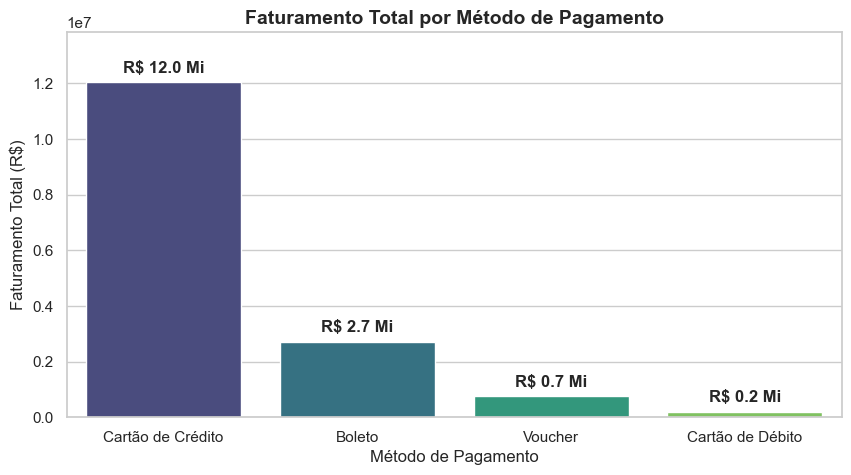

In [8]:
# Fazer o merge com a base de pagamentos (caso ainda não esteja feito na memória)
df_pagamentos = df.merge(pagamentos_raw[['order_id', 'payment_type']], on='order_id', how='inner')

# Agrupar por método de pagamento e somar a receita líquida (faturamento)
faturamento_pagamento = df_pagamentos[df_pagamentos['payment_type'] != 'not_defined'].groupby('payment_type').agg(
    faturamento_total=('receita_liquida', 'sum')
).reset_index()

# Traduzir os rótulos para Português
traducao = {'credit_card': 'Cartão de Crédito', 'boleto': 'Boleto', 'voucher': 'Voucher', 'debit_card': 'Cartão de Débito'}
faturamento_pagamento['payment_type'] = faturamento_pagamento['payment_type'].map(traducao)

# Ordenar do maior para o menor faturamento
faturamento_pagamento = faturamento_pagamento.sort_values(by='faturamento_total', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='payment_type', y='faturamento_total', data=faturamento_pagamento, palette='viridis')

plt.title('Faturamento Total por Método de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Método de Pagamento')
plt.ylabel('Faturamento Total (R$)')

# Adicionar os valores em Milhões (Mi) em cima de cada barra
for p in ax.patches:
    valor = p.get_height()
    ax.annotate(f"R$ {valor/1000000:.1f} Mi", (p.get_x() + p.get_width() / 2., valor), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold', fontsize=12)

# Ajustar limite Y para o texto não cortar
plt.ylim(0, faturamento_pagamento['faturamento_total'].max() * 1.15)
plt.show()

> **💡 Insight de Negócio: O Abismo Financeiro**
> O gráfico demonstra que o **Cartão de Crédito** não é apenas o método mais popular, mas é o motor financeiro absoluto da empresa, esmagando todos os outros métodos somados. 

### ☢️ 8. As Categorias com piores avaliações

C:\Users\Almox\AppData\Local\Temp\ipykernel_15152\2760553965.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='nota_media', y='product_category_name_english', data=piores_categorias, palette='Reds_r')


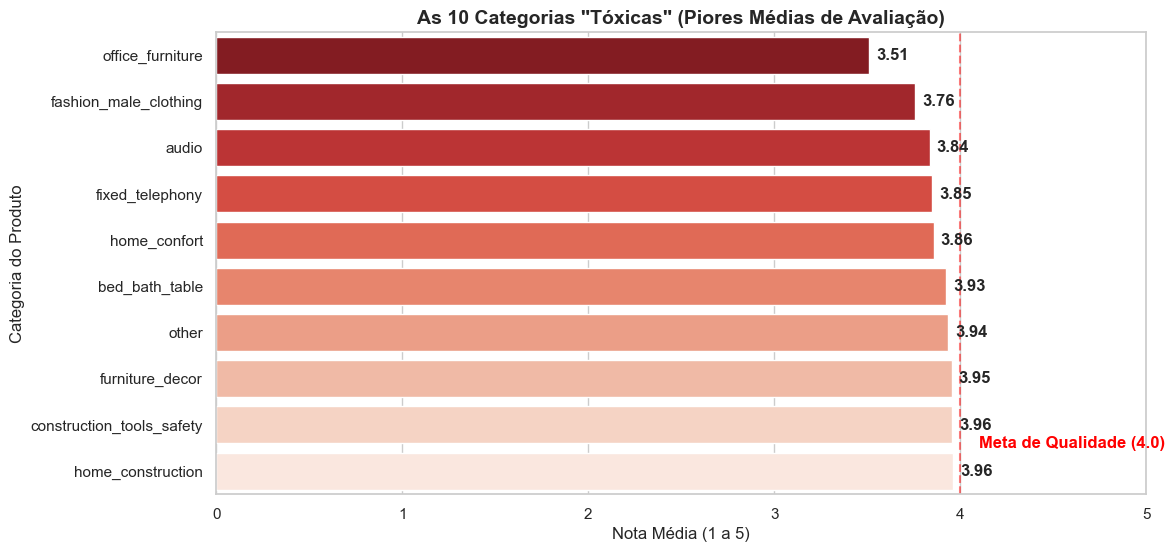

In [9]:
# Agrupar por categoria para calcular a nota média e o volume de vendas
avaliacoes_categoria = df.groupby('product_category_name_english').agg(
    nota_media=('review_score', 'mean'),
    volume=('order_id', 'count')
).reset_index()

# Filtrar apenas categorias com mais de 50 vendas (para evitar que 1 único produto ruim suje os dados)
avaliacoes_categoria = avaliacoes_categoria[avaliacoes_categoria['volume'] > 50]

# Pegar as 10 categorias com as piores notas
piores_categorias = avaliacoes_categoria.nsmallest(10, 'nota_media')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='nota_media', y='product_category_name_english', data=piores_categorias, palette='Reds_r')

plt.title('As 10 Categorias "Tóxicas" (Piores Médias de Avaliação)', fontsize=14, fontweight='bold')
plt.xlabel('Nota Média (1 a 5)')
plt.ylabel('Categoria do Produto')

# Linha de alerta vermelho marcando a nota 4.0 (Aceitável)
plt.axvline(4.0, color='red', linestyle='--', alpha=0.5)
plt.annotate('Meta de Qualidade (4.0)', xy=(4.0, 8.5), xytext=(4.1, 8.5), color='red', fontweight='bold')

# Adicionar a nota exata dentro/ao lado das barras
for p in ax.patches:
    nota = p.get_width()
    ax.annotate(f"{nota:.2f}", (nota, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.xlim(0, 5)
plt.show()

> **💡 Insight de Negócio: Os Destruidores de Reputação**
> Esta análise expõe as categorias que geram a maior frustração e atrito com os clientes. Categorias como **Móveis de Escritório (Office Furniture)** e **Telefonia** têm consistentemente as piores notas da plataforma, ficando muito abaixo da meta de qualidade da empresa (4 estrelas).

### 💳 9. Comparativo: Métodos de Pagamento nas Principais Categorias

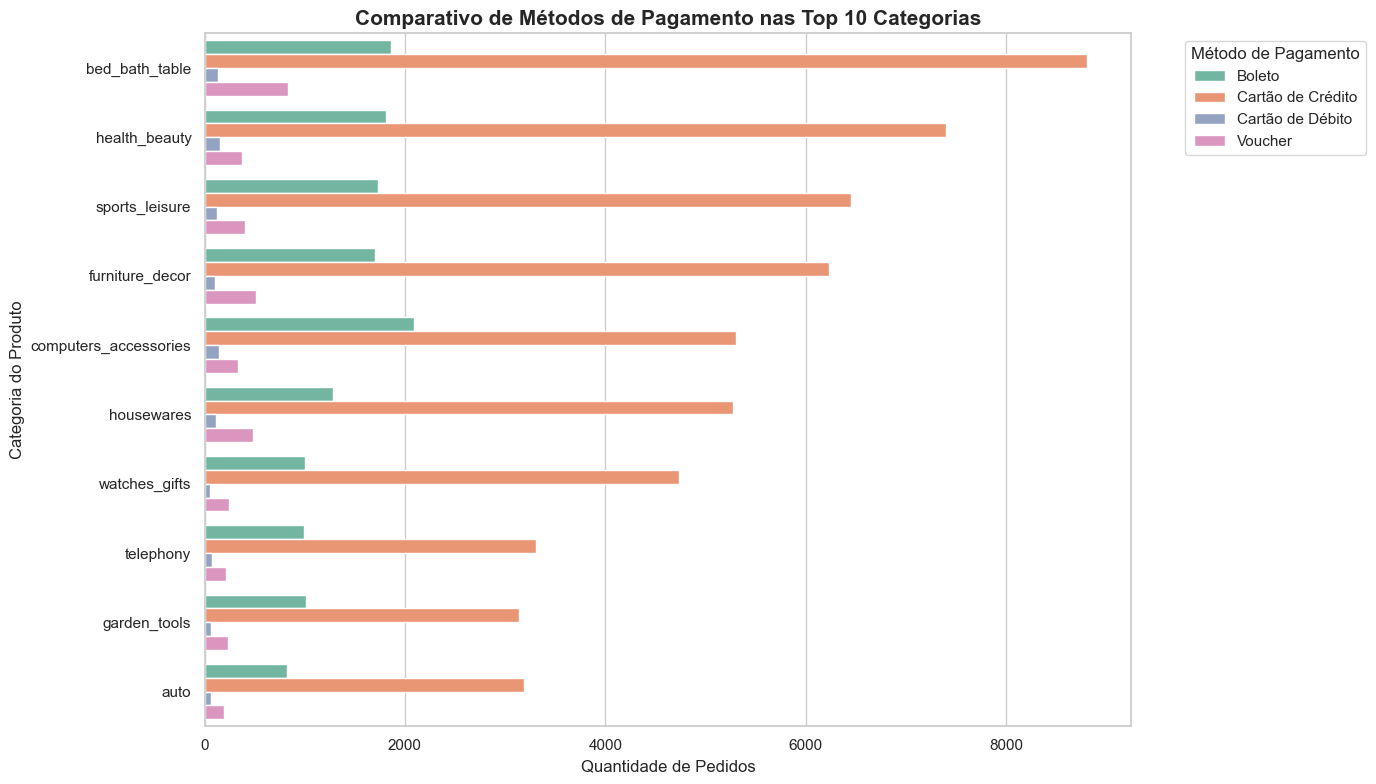

In [10]:
# 1. Identificar as Top 10 categorias com maior volume de vendas
top_10_categorias = df['product_category_name_english'].value_counts().nlargest(10).index

# 2. Filtrar o dataset principal apenas para estas categorias
df_top_cats = df[df['product_category_name_english'].isin(top_10_categorias)]

# 3. Fazer o merge com a base de pagamentos
df_cat_pagamentos = df_top_cats.merge(pagamentos_raw[['order_id', 'payment_type']], on='order_id', how='inner')

# 4. Limpar e traduzir os métodos de pagamento
df_cat_pagamentos = df_cat_pagamentos[df_cat_pagamentos['payment_type'] != 'not_defined']
traducao = {'credit_card': 'Cartão de Crédito', 'boleto': 'Boleto', 'voucher': 'Voucher', 'debit_card': 'Cartão de Débito'}
df_cat_pagamentos['payment_type'] = df_cat_pagamentos['payment_type'].map(traducao)

# 5. Agrupar por Categoria e Método de Pagamento
analise_cat_pag = df_cat_pagamentos.groupby(['product_category_name_english', 'payment_type']).size().reset_index(name='volume_pedidos')

# 6. Ordenar para o gráfico ficar organizado (pelo volume total da categoria)
ordem_categorias = df_cat_pagamentos['product_category_name_english'].value_counts().index

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=analise_cat_pag, 
    x='volume_pedidos', 
    y='product_category_name_english', 
    hue='payment_type', 
    order=ordem_categorias,
    palette='Set2'
)

plt.title('Comparativo de Métodos de Pagamento nas Top 10 Categorias', fontsize=15, fontweight='bold')
plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Categoria do Produto')

# Ajustar a legenda para não sobrepor o gráfico
plt.legend(title='Método de Pagamento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Garante que nada fica cortado na exportação da imagem

plt.show()

> **💡 Insight de Negócio: O Padrão de Consumo Multicategoria**
> O gráfico demonstra que a hegemonia do **Cartão de Crédito** é absoluta e se mantém intacta independente do nicho (desde Cama/Mesa/Banho até Informática). No entanto, o **Boleto Bancário** apresenta uma força considerável em categorias como *Computer Accessories* (Acessórios de Informática) e *Health & Beauty* (Saúde e Beleza).

### 🗺️ 10. O Mapa de Interesses: A Categoria Campeã por Estado

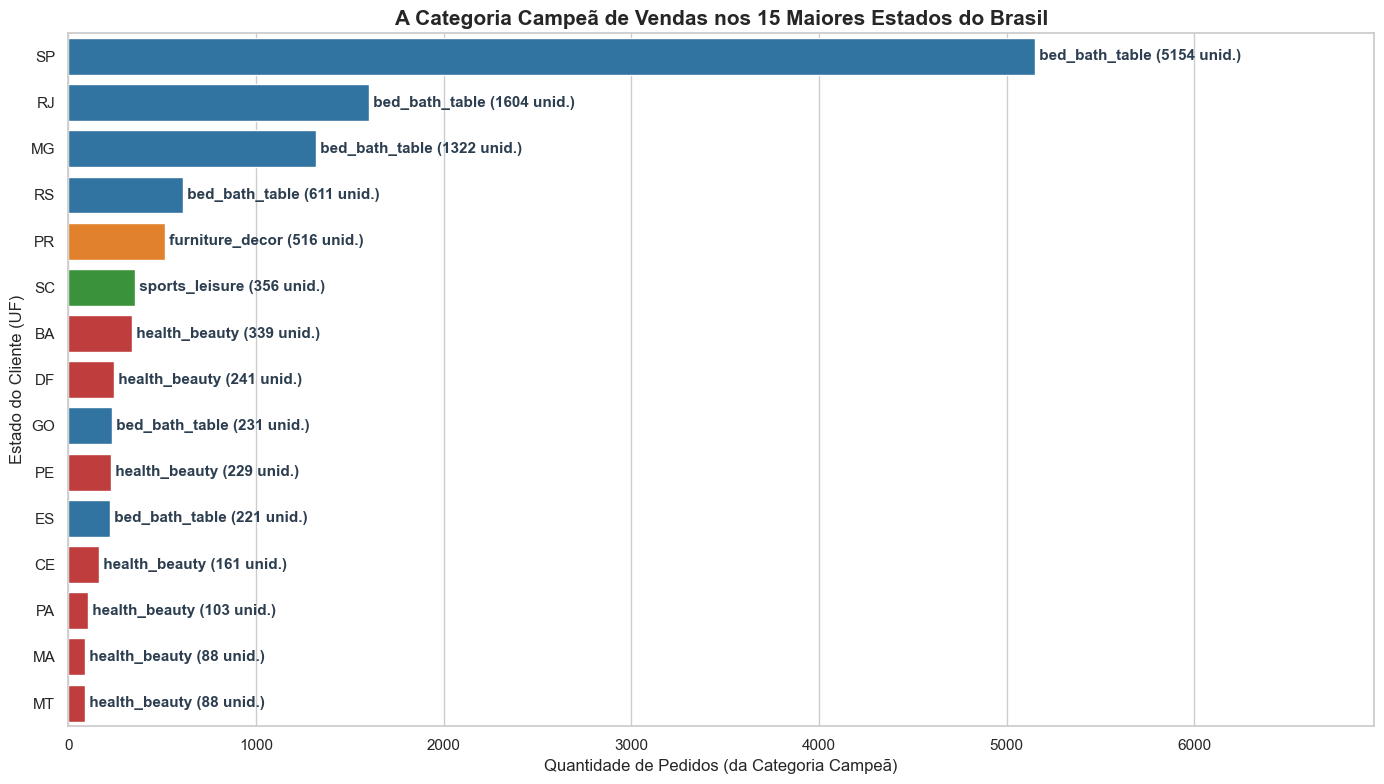

In [11]:
# 1. Contar as vendas agrupadas por Estado e por Categoria
vendas_estado_cat = df.groupby(['customer_state', 'product_category_name_english']).size().reset_index(name='quantidade_vendas')

# 2. Descobrir a categoria com o número MÁXIMO de vendas para cada estado
idx_campeas = vendas_estado_cat.groupby('customer_state')['quantidade_vendas'].idxmax()
campeas_por_estado = vendas_estado_cat.loc[idx_campeas]

# 3. Ordenar do estado que mais vende para o que menos vende, e pegar o Top 15 para legibilidade
campeas_por_estado = campeas_por_estado.sort_values(by='quantidade_vendas', ascending=False).head(15)

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x='quantidade_vendas', 
    y='customer_state', 
    data=campeas_por_estado, 
    hue='product_category_name_english',
    dodge=False,
    palette='tab10'
)

plt.title('A Categoria Campeã de Vendas nos 15 Maiores Estados do Brasil', fontsize=15, fontweight='bold')
plt.xlabel('Quantidade de Pedidos (da Categoria Campeã)')
plt.ylabel('Estado do Cliente (UF)')

# 4. Magia visual: Escrever o nome da categoria diretamente à frente de cada barra
for i in range(len(campeas_por_estado)):
    largura = campeas_por_estado.iloc[i]['quantidade_vendas']
    categoria = campeas_por_estado.iloc[i]['product_category_name_english']
    
    # Desenhar o texto (nome da categoria e quantidade)
    ax.annotate(f" {categoria} ({int(largura)} unid.)", 
                (largura, i), 
                ha='left', va='center', fontweight='bold', fontsize=11, color='#2c3e50')

# Remover a legenda padrão para não poluir o gráfico (já que o texto está nas barras)
ax.get_legend().remove()

# Aumentar o limite do eixo X em 35% para garantir que o texto não fica cortado
plt.xlim(0, campeas_por_estado['quantidade_vendas'].max() * 1.35) 
plt.tight_layout()
plt.show()

> **💡 Insight de Negócio: O Comportamento de Consumo Regional**
> Embora o Brasil seja um país de dimensões continentais, as necessidades básicas de e-commerce mostram uma hegemonia clara: categorias focadas no bem-estar pessoal e do lar (como **Cama, Mesa e Banho** e **Beleza e Saúde**) dominam como as preferências absolutas, independentemente da região. 

### ⚖️ 11. Alto Volume vs. Baixa Margem (Ticket)

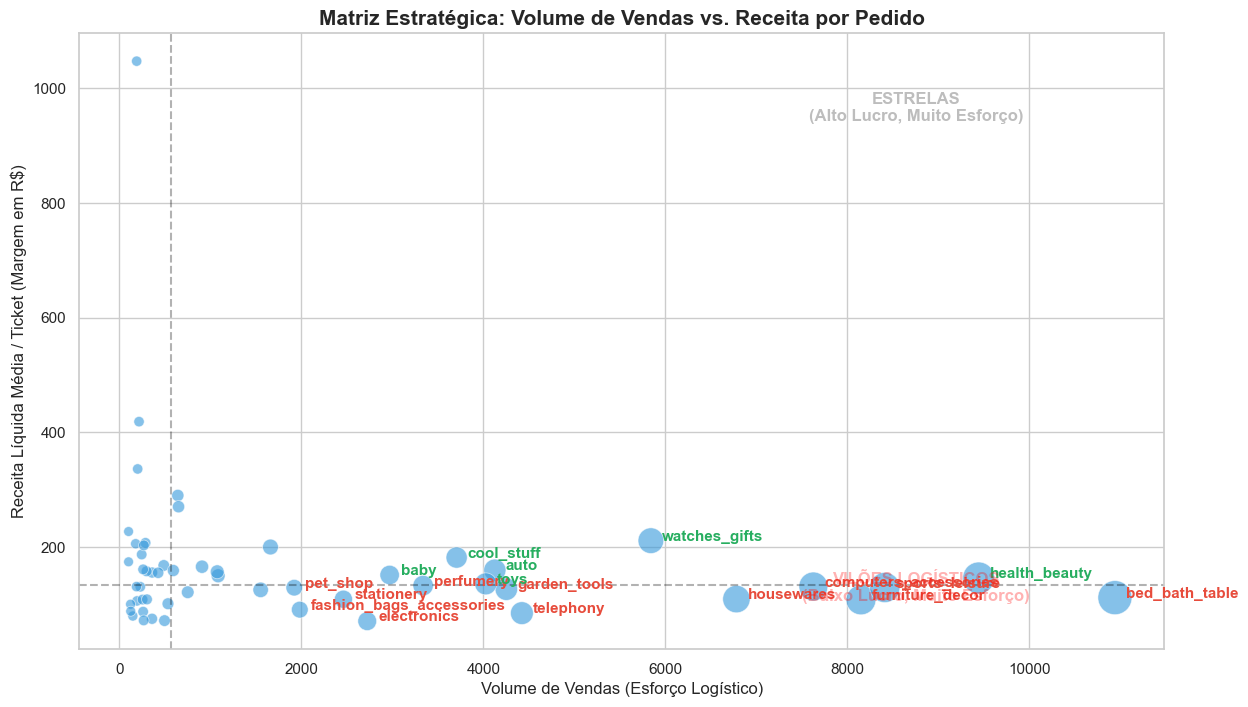

In [12]:
# 1. Agrupar os dados por categoria calculando Volume e Ticket Médio
analise_matriz = df.groupby('product_category_name_english').agg(
    volume_vendas=('order_id', 'count'),
    ticket_medio=('receita_liquida', 'mean')
).reset_index()

# 2. Filtrar o "ruído" (categorias com menos de 100 vendas que poluem o gráfico)
analise_matriz = analise_matriz[analise_matriz['volume_vendas'] > 100]

# 3. Calcular a mediana para desenhar as linhas dos quadrantes
mediana_volume = analise_matriz['volume_vendas'].median()
mediana_ticket = analise_matriz['ticket_medio'].median()

# 4. Desenhar o Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    x='volume_vendas', 
    y='ticket_medio', 
    data=analise_matriz, 
    size='volume_vendas', 
    sizes=(50, 600), # Bolhas maiores para volumes maiores
    alpha=0.6, 
    color='#3498db',
    legend=False
)

# 5. Desenhar a "Cruz" dos quadrantes
plt.axvline(mediana_volume, color='black', linestyle='--', alpha=0.3)
plt.axhline(mediana_ticket, color='black', linestyle='--', alpha=0.3)

plt.title('Matriz Estratégica: Volume de Vendas vs. Receita por Pedido', fontsize=15, fontweight='bold')
plt.xlabel('Volume de Vendas (Esforço Logístico)')
plt.ylabel('Receita Líquida Média / Ticket (Margem em R$)')

# 6. Escrever o nome das categorias mais extremas (Para não poluir, filtramos os destaques)
for i in range(len(analise_matriz)):
    vol = analise_matriz['volume_vendas'].iloc[i]
    tick = analise_matriz['ticket_medio'].iloc[i]
    cat = analise_matriz['product_category_name_english'].iloc[i]
    
    # Destacar os vilões do Alto Volume / Baixo Ticket (Canto inferior direito) em VERMELHO
    if vol > mediana_volume * 3 and tick < mediana_ticket:
        ax.annotate(cat, (vol, tick), xytext=(8, 0), textcoords='offset points', 
                    fontweight='bold', color='#e74c3c', fontsize=11)
        
    # Destacar as "Estrelas" de Alto Volume / Alto Ticket (Canto superior direito) em VERDE
    elif vol > mediana_volume * 3 and tick >= mediana_ticket:
        ax.annotate(cat, (vol, tick), xytext=(8, 0), textcoords='offset points', 
                    fontweight='bold', color='#27ae60', fontsize=11)

# Adicionar textos explicativos dos quadrantes
plt.annotate('ESTRELAS\n(Alto Lucro, Muito Esforço)', xy=(analise_matriz['volume_vendas'].max() * 0.8, analise_matriz['ticket_medio'].max() * 0.9), 
             alpha=0.3, fontweight='bold', ha='center')
plt.annotate('VILÕES LOGÍSTICOS\n(Baixo Lucro, Muito Esforço)', xy=(analise_matriz['volume_vendas'].max() * 0.8, analise_matriz['ticket_medio'].min() * 1.5), 
             alpha=0.3, fontweight='bold', ha='center', color='red')

plt.show()

> **💡 Insight de Negócio: Os "Vilões Logísticos" vs. "Estrelas"**
> Esta matriz de quadrantes revela a eficiência da operação. As categorias destacadas em **vermelho** no quadrante inferior direito (como *Telephony* e *Bed/Bath/Table*) são produtos de altíssimo giro, mas com um ticket médio muito baixo. Elas exigem um esforço logístico colossal (embalar, enviar, rastrear milhares de caixas), mas deixam uma margem financeira apertada no final.